Shape: (30336, 12)


,Unnamed: 0,name,online_order,book_table,rating,votes,location,rest_type,dish_liked,cuisines,approx_cost,type
0,0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


Index(['Unnamed: 0', 'name', 'online_order', 'book_table', 'rating', 'votes',
       'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost',
       'type'],
      dtype='str')
Unnamed: 0          0
name                0
online_order        0
book_table          0
rating              0
votes               0
location            0
rest_type         107
dish_liked      13213
cuisines            6
approx_cost         0
type             2584
dtype: int64


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_10522/2308597291.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


TF-IDF Shape: (30336, 2000)
Silhouette Scores:
{2: 0.028326606718959053, 3: 0.031968367924844934, 4: 0.03217792708798382, 5: 0.030855605834269512, 6: 0.032863935626466605, 7: 0.03530651181625253}
Best K: 7

Cluster Counts:
cluster
0    6534
1    5350
2    3150
3    3572
4    1315
5    8555
6    1860
Name: count, dtype: int64

Cluster 0:
indian, bites, quick, south, north, chinese, delivery, dineout, yes, restaurant

Cluster 1:
food, fast, bites, quick, delivery, yes, street, dineout, shop, rolls

Cluster 2:
cafe, cafes, pizza, pasta, yes, coffee, burger, continental, burgers, italian

Cluster 3:
biryani, chicken, delivery, indian, andhra, north, yes, casual, dining, mutton

Cluster 4:
bakery, desserts, cake, delivery, chocolate, yes, dessert, parlor, cafe, road

Cluster 5:
dining, casual, yes, chicken, indian, north, chinese, bar, pizza, continental

Cluster 6:
desserts, cream, ice, dessert, parlor, chocolate, beverages, yes, delivery, waffles


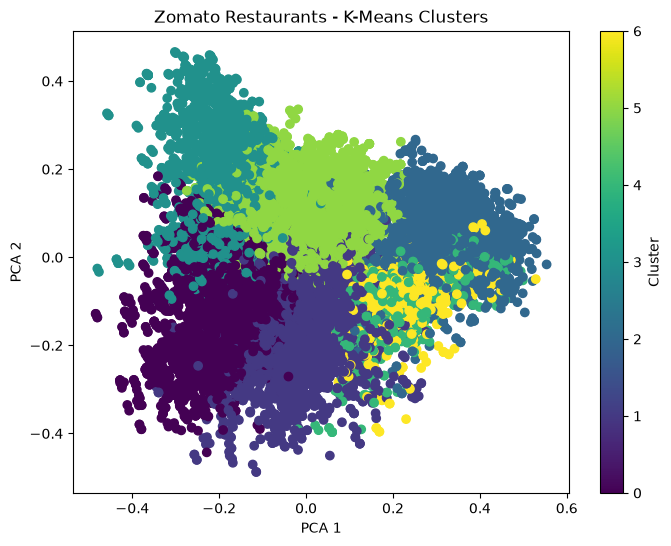


Completed!
Saved as: zomato_kmeans_clustered.csv


In [2]:
# ==========================================================
# ZOMATO DATASET - NLP + K-MEANS CLUSTERING
# ==========================================================

# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 2. Load dataset
df = pd.read_csv("zomatocleaned1.csv")

print("Shape:", df.shape)
display(df.head())

# 3. Check columns and missing values
print(df.columns)
print(df.isnull().sum())

# 4. Select text columns automatically
text_cols = df.select_dtypes(include="object").columns

# Combine all text columns
df["text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

# 5. Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

# 6. Convert text into TF-IDF
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=2000
)

X = tfidf.fit_transform(df["clean_text"])

print("TF-IDF Shape:", X.shape)

# 7. Find best K using Silhouette Score
scores = {}

for k in range(2, 8):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X)
    scores[k] = silhouette_score(X, labels)

print("Silhouette Scores:")
print(scores)

best_k = max(scores, key=scores.get)
print("Best K:", best_k)

# 8. Final K-Means model
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X)

# 9. Cluster sizes
print("\nCluster Counts:")
print(df["cluster"].value_counts().sort_index())

# 10. Top words in each cluster
terms = tfidf.get_feature_names_out()

for i in range(best_k):
    words = kmeans.cluster_centers_[i].argsort()[-10:][::-1]
    print(f"\nCluster {i}:")
    print(", ".join(terms[words]))

# 11. PCA visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"],
    cmap="viridis"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Zomato Restaurants - K-Means Clusters")
plt.colorbar(label="Cluster")
plt.show()

# 12. Save results
df.to_csv(
    "zomato_kmeans_clustered.csv",
    index=False
)

print("\nCompleted!")
print("Saved as: zomato_kmeans_clustered.csv")

